## 🏁 Conclusion

### 📊 Resumen del Flujo
1. **Preparación de Datos:** Se cargó el dataset técnico y se vectorizaron los textos utilizando `TfidfVectorizer` (limitado a las 1000 características más importantes).
2. **Evaluación de Modelos:** Se probaron tres arquitecturas distintas (`DecisionTree`, `RandomForest` y `GradientBoosting`).
3. **Optimización:** El modelo de Gradient Boosting (`gbm`) demostró el mejor rendimiento inicial, por lo que se procedió a la optimización de sus hiperparámetros mediante `GridSearchCV`.
4. **Resultados Finales:** Se logró un excelente desempeño con un **F1-score (macro) en validación de ~0.9717**.

### 📦 Artefactos Exportados para Producción
Se generaron y serializaron los siguientes archivos listos para ser integrados en el Back-End:
* `modelo_entrenado.pkl`: Contiene el clasificador optimizado (GBM).
* `vectorizer.pkl`: Contiene el vocabulario y pesos de TF-IDF necesarios para transformar nuevos textos de entrada con la misma estructura.

In [ ]:
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, accuracy_score

class ModeloTexto:
    def __init__(self, X, y, algoritmo='tree'):
        """
        X: Matriz de texto ya vectorizada (numérica, ej. salida de TF-IDF)
        y: Etiquetas/Categorías (pueden ser strings como 'Backend', 'Frontend')
        """
        self.X = X
        self.y = y
        self.algoritmos = {
            'tree':   DecisionTreeClassifier(random_state=5),
            'forest': RandomForestClassifier(random_state=5),
            'gbm':    GradientBoostingClassifier(random_state=5)
        }
        if algoritmo not in self.algoritmos:
            raise ValueError(f'Algoritmo no válido. Elegí entre: {list(self.algoritmos.keys())}')

        self.modelo = self.algoritmos[algoritmo]
        self.algoritmo = algoritmo

    def split(self):
        X_temp, self.X_test, y_temp, self.y_test = train_test_split(
            self.X, self.y, test_size=0.15, stratify=self.y, random_state=5
        )
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_temp, y_temp, stratify=y_temp, random_state=5
        )
        return self

    def entrenar(self):
        self.modelo.fit(self.X_train, self.y_train)
        y_pred_val = self.modelo.predict(self.X_val)

        print(f'Algoritmo: {self.algoritmo}')
        print(f'Exactitud en entrenamiento:   {self.modelo.score(self.X_train, self.y_train):.4f}')
        print(f'Exactitud en validación:      {self.modelo.score(self.X_val, self.y_val):.4f}')

        # Usamos average='macro' para promediar el F1-score de todas las categorías
        print(f'F1-score (macro) en val:      {f1_score(self.y_val, y_pred_val, average="macro"):.4f}')
        print(f'La exactitud (accuracy) es:   {accuracy_score(self.y_val, y_pred_val):.4f}\n')

        return self

    def optimizar(self):
        params = {
            'tree':   {'max_depth': range(1, 15), 'min_samples_split': [2, 5, 10]},
            'forest': {'max_depth': range(1, 15), 'n_estimators': [50, 100]},
            'gbm':    {'max_depth': [3, 5],       'n_estimators': [50, 100]}
        }
        grid = GridSearchCV(self.modelo, params[self.algoritmo], cv=3, scoring='f1_macro')
        grid.fit(self.X_train, self.y_train)
        self.modelo = grid.best_estimator_
        print(f'Mejores parámetros: {grid.best_params_}')
        print(f'Mejor F1-score en CV: {grid.best_score_:.4f}')
        return self

    def evaluar(self):
        y_previsto = self.modelo.predict(self.X_test)
        print(classification_report(self.y_test, y_previsto))

        # Mostramos la matriz de confusión con las categorías reales
        ConfusionMatrixDisplay.from_predictions(
            self.y_test,
            y_previsto,
            xticks_rotation=45
        )
        return self

    def probar_ejemplos(self, X_num):
        """
        Recibe la matriz X ya vectorizada, predice las categorías
        e imprime los resultados
        """
        predicciones = self.modelo.predict(X_num)
        probabilidades = self.modelo.predict_proba(X_num)

        print("--- 🧪 RESULTADOS DE INFERENCIA --- \n")

        for i, (categoria, proba) in enumerate(zip(predicciones, probabilidades), 1):
            confianza_maxima = max(proba) * 100
            print(f"🔹 Muestra #{i}: Categoría --> {categoria.upper()} <-- (Confianza: {confianza_maxima:.1f}%)")

        print("-" * 50)


    def guardar_modelo(self, filename='modelo_ganador.pkl'):
        """Guarda el modelo clasificador para que el Back-End lo pueda consumir."""
        try:
            with open(filename, 'wb') as archivo:
                joblib.dump(self.modelo, archivo)
            print(f"Modelo guardado exitosamente en: '{filename}'")

        except IOError as e:
            print(f"Error de Entrada/Salida al intentar guardar el modelo: {e}")
        except Exception as e:
            print(f"Ocurrió un error inesperado al serializar el modelo: {e}")

        return self

Algoritmo: forest
Exactitud en entrenamiento:   1.0000
Exactitud en validación:      0.9741
F1-score (macro) en val:      0.9743
La exactitud (accuracy) es:   0.9741

              precision    recall  f1-score   support

     android       1.00      1.00      1.00        33
          c#       0.94      0.97      0.96        33
         c++       1.00      0.94      0.97        33
        html       1.00      0.97      0.99        34
        java       0.94      1.00      0.97        34
  javascript       1.00      1.00      1.00        34
      jquery       0.94      1.00      0.97        33
         php       1.00      0.97      0.98        33
      python       1.00      0.97      0.98        33

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



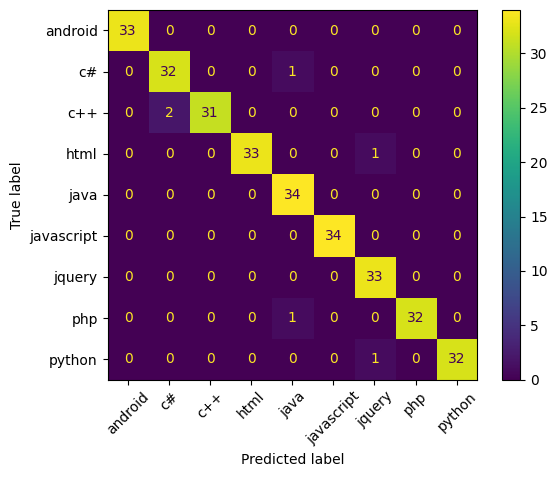

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Cargar dataset técnico
df = pd.read_csv('datos_tecnicos.csv') # Columnas: 'texto', 'categoria'

# Vectorizar el texto
vectorizer = TfidfVectorizer(max_features=1000) # Elegimos las 1000 palabras mas importantes
X_vectorizado = vectorizer.fit_transform(df['texto'])
y = df['categoria']


# Entrenar Random Forest
modelo_1 = ModeloTexto(X_vectorizado, y, algoritmo='forest')

# Pipeline completo
modelo_1.split().entrenar().evaluar()


Algoritmo: gbm
Exactitud en entrenamiento:   1.0000
Exactitud en validación:      0.9812
F1-score (macro) en val:      0.9814
La exactitud (accuracy) es:   0.9812

              precision    recall  f1-score   support

     android       1.00      0.94      0.97        33
          c#       0.97      0.97      0.97        33
         c++       0.97      0.97      0.97        33
        html       1.00      0.97      0.99        34
        java       0.94      1.00      0.97        34
  javascript       1.00      1.00      1.00        34
      jquery       0.97      1.00      0.99        33
         php       0.97      0.97      0.97        33
      python       1.00      1.00      1.00        33

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



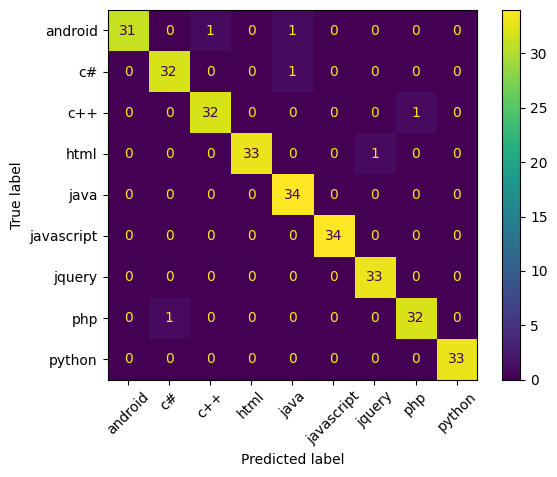

In [ ]:
# Entrenar Gradient Boost
modelo_2 = ModeloTexto(X_vectorizado, y, algoritmo='gbm')

# Pipeline completo
modelo_2.split().entrenar().evaluar()


Algoritmo: tree
Exactitud en entrenamiento:   1.0000
Exactitud en validación:      0.9506
F1-score (macro) en val:      0.9505
La exactitud (accuracy) es:   0.9506

              precision    recall  f1-score   support

     android       0.91      0.91      0.91        33
          c#       0.91      0.91      0.91        33
         c++       0.94      0.91      0.92        33
        html       1.00      0.97      0.99        34
        java       0.94      0.97      0.96        34
  javascript       0.97      1.00      0.99        34
      jquery       0.92      1.00      0.96        33
         php       0.94      0.97      0.96        33
      python       1.00      0.88      0.94        33

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



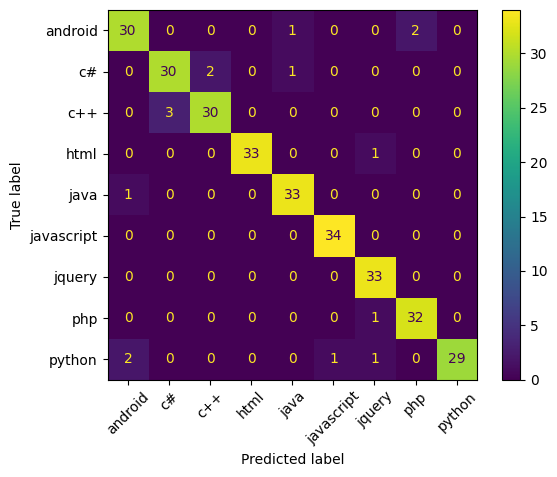

In [ ]:
# Entrenar Decision Tree
modelo_3 = ModeloTexto(X_vectorizado, y, algoritmo='tree')

# Pipeline completo
modelo_3.split().entrenar().evaluar()


In [ ]:
# Definimos una lista de textos nuevos para probar
textos_de_prueba = [
    "uso $('#form').on('submit') para validar antes de mandar el fetch",
    "los hooks de React tipo useEffect me tienen loco con las dependencias",
    "la anotación @Autowired no me inyecta el bean, revisar el application.yml",
    "en .NET uso LINQ para filtrar la lista antes de mapearla al DTO",
    "el RecyclerView no refresca los items después del notifyDataSetChanged",
    "el endpoint /api/users me tira 500 en el middleware de auth"
]

# Pasamos el texto por el Vectorizador
X_nuevos = vectorizer.transform(textos_de_prueba)

modelo_1.probar_ejemplos(X_nuevos)


--- 🧪 RESULTADOS DE INFERENCIA --- 

🔹 Muestra #1: Categoría --> C# <-- (Confianza: 25.0%)
🔹 Muestra #2: Categoría --> JAVASCRIPT <-- (Confianza: 84.0%)
🔹 Muestra #3: Categoría --> JAVASCRIPT <-- (Confianza: 19.0%)
🔹 Muestra #4: Categoría --> C# <-- (Confianza: 66.0%)
🔹 Muestra #5: Categoría --> ANDROID <-- (Confianza: 40.0%)
🔹 Muestra #6: Categoría --> C# <-- (Confianza: 28.0%)
--------------------------------------------------


In [ ]:
modelo_2.probar_ejemplos(X_nuevos)


--- 🧪 RESULTADOS DE INFERENCIA --- 

🔹 Muestra #1: Categoría --> C# <-- (Confianza: 40.3%)
🔹 Muestra #2: Categoría --> JAVASCRIPT <-- (Confianza: 97.8%)
🔹 Muestra #3: Categoría --> C# <-- (Confianza: 24.1%)
🔹 Muestra #4: Categoría --> C# <-- (Confianza: 98.3%)
🔹 Muestra #5: Categoría --> ANDROID <-- (Confianza: 69.9%)
🔹 Muestra #6: Categoría --> C# <-- (Confianza: 24.1%)
--------------------------------------------------


In [ ]:
modelo_2.optimizar()

Mejores parámetros: {'max_depth': 5, 'n_estimators': 100}
Mejor F1-score en CV: 0.9717


              precision    recall  f1-score   support

     android       1.00      1.00      1.00        33
          c#       0.97      0.97      0.97        33
         c++       1.00      0.97      0.98        33
        html       1.00      0.97      0.99        34
        java       0.97      1.00      0.99        34
  javascript       1.00      1.00      1.00        34
      jquery       0.97      1.00      0.99        33
         php       0.97      0.97      0.97        33
      python       1.00      1.00      1.00        33

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



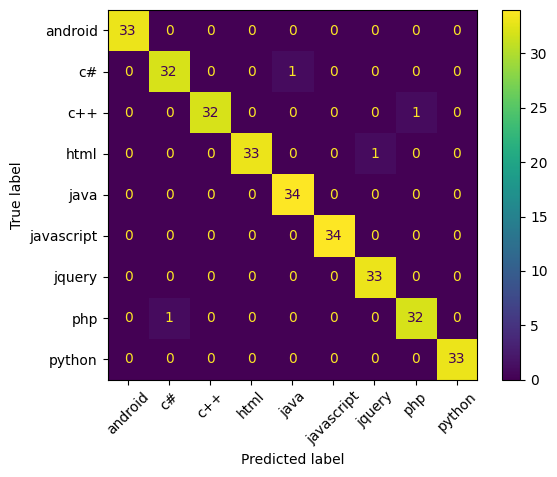

In [ ]:
modelo_2.evaluar()

In [ ]:
modelo_2.guardar_modelo()

try:
    with open('vectorizer.pkl', 'wb') as f:
        joblib.dump(vectorizer, f)
    print("Vectorizador guardado exitosamente en: 'vectorizer.pkl'")
except Exception as e:
    print(f"Error al guardar el vectorizador: {e}")


Modelo guardado exitosamente en: 'modelo_ganador.pkl'
Vectorizador guardado exitosamente en: 'vectorizer.pkl'
